# **Exploratory Data Analysis and Topic Modeling**
notebook by Jan Eliel Bualoy \
*from [JNV Teaching Notebooks](https://github.com/JNV-Teaching/teaching)*

Instructions: Implement EDA and Topic Modeling on your collected dataset from Data Collection.


# Pre-processing Data

In [ ]:
!pip install nltk

In [ ]:
import pandas as pd
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords

In [ ]:
# Load data
rappler_docs = pd.read_excel('rappler_corpus.xlsx')
youtube_docs = pd.read_excel('youtube_corpus.xlsx')

## Inspecting the data

In [ ]:
display(
  rappler_docs.head(1)
)
display(
  youtube_docs.head(1)
)

rappler_docs.info()
youtube_docs.info()

,Unnamed: 0,title,date_published,link,text,tags
0,0,"DPWH seeks lookout order vs officials, contrac...",2025-09-03T12:44:03+08:00,https://www.rappler.com/philippines/dpwh-seeks...,"MANILA, Philippines – The Department of Public...","['Budget Watch', 'Bureau of Immigration', 'cor..."


,Unnamed: 0,title,link,date_published,text,like_count,reply_parent_id
0,0,Invite niyo si magalong at Zaldy Co bat ba aya...,https://www.youtube.com/watch?v=1GbouN7n5lQ&lc...,2025-09-03T06:07:34Z,Invite niyo si magalong at Zaldy Co bat ba aya...,0,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Unnamed: 0      150 non-null    int64 
 1   title           150 non-null    object
 2   date_published  150 non-null    object
 3   link            150 non-null    object
 4   text            150 non-null    object
 5   tags            150 non-null    object
dtypes: int64(1), object(5)
memory usage: 7.2+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8473 entries, 0 to 8472
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Unnamed: 0       8473 non-null   int64 
 1   title            8473 non-null   object
 2   link             8473 non-null   object
 3   date_published   8473 non-null   object
 4   text             8473 non-null   object
 5   like_count       8473 non-null   int64 
 6   reply_parent_id  431 no

## Converting to datetime data type



In [ ]:
# Standardize date_published column
# Rappler docs come in +08:00 timezone
rappler_docs['date_published'] = pd.to_datetime(
    rappler_docs['date_published']).dt.tz_convert(tz='Asia/Manila').dt.tz_localize(None)
# Youtube docs come in UTC timezone
youtube_docs['date_published'] = pd.to_datetime(
    youtube_docs['date_published']).dt.tz_convert(tz='Asia/Manila').dt.tz_localize(None)


In [ ]:
# Convert date_published as datetime data type
rappler_docs['date_published'] = pd.to_datetime(
  rappler_docs['date_published']
)

youtube_docs['date_published'] = pd.to_datetime(
  youtube_docs['date_published']
)

In [ ]:
# Combine the two corpus
# Assign source to each corpus
rappler_docs['source'] = 'rappler'
youtube_docs['source'] = 'youtube'

In [ ]:
# Combine the two corpus
docs = pd.concat([
  rappler_docs, youtube_docs
], ignore_index=True, axis=0)
display(docs.head(1))
display(docs.tail(1))

,Unnamed: 0,title,date_published,link,text,tags,source,like_count,reply_parent_id
0,0,"DPWH seeks lookout order vs officials, contrac...",2025-09-03 12:44:03,https://www.rappler.com/philippines/dpwh-seeks...,"MANILA, Philippines – The Department of Public...","['Budget Watch', 'Bureau of Immigration', 'cor...",rappler,NaN,NaN


,Unnamed: 0,title,date_published,link,text,tags,source,like_count,reply_parent_id
8622,795,I liked her/Congress woman Laila de lima,2025-08-21 13:36:08,https://www.youtube.com/watch?v=IpoKMx9mquw&lc...,I liked her/Congress woman Laila de lima,NaN,youtube,0.0,NaN


## Clean corpus

In [ ]:
from pandas.errors import EmptyDataError

try:
  basic_stopwords = list(
    # Handle empty data error
    pd.read_csv('basic_stopwords.txt', header=None).values.flatten()
  )
except EmptyDataError:
  basic_stopwords = []

try:
  domain_stopwords = list(
    pd.read_csv('domain_stopwords.txt', header=None).values.flatten()
  )
except EmptyDataError:
  domain_stopwords = []

try:
  tagalog_stopwords = list(
    pd.read_csv('tagalog_stopwords.txt', header=None).values.flatten()
  )
except EmptyDataError:
  tagalog_stopwords = []

In [ ]:
import nltk
import emoji
import unicodedata
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('stopwords')

lemmatizer = WordNetLemmatizer()
stopwords = stopwords.words('english')


def clean_docs(docs):

  # Transform into lowercase strings
  docs['cleaned_text'] = docs['text'].astype(str).str.lower()

  # Unicode normalization
  docs['cleaned_text'] = docs['cleaned_text'].apply(
    lambda x: unicodedata.normalize("NFKD", x))

  # Remove NaN values
  docs['cleaned_text'] = docs['cleaned_text'].replace(np.nan, '', regex=True)

  # Remove usernames, non-alphanumeric characters, and links
  docs['cleaned_text'] = docs['cleaned_text'].str.replace(r'[^\w\s]', ' ', regex=True)

  # Lemmatize verbs
  docs['cleaned_text'] = docs['cleaned_text'].apply(
    lambda row: ' '.join([lemmatizer.lemmatize(x, 'v') for x in row.split()]))

  # Lemmatize adjectives
  docs['cleaned_text'] = docs['cleaned_text'].apply(
    lambda row: ' '.join([lemmatizer.lemmatize(x, 'a') for x in row.split()]))

  # Lemmatize nouns
  docs['cleaned_text'] = docs['cleaned_text'].apply(
    lambda row: ' '.join([lemmatizer.lemmatize(x, 'n') for x in row.split()]))

  # Remove trailing and leading whitespaces
  docs['cleaned_text'] = docs['cleaned_text'].str.replace(r'\s+', ' ', regex=True).str.strip()

  # Remove numbers
  docs['cleaned_text'] = docs['cleaned_text'].str.replace(r'\d+', ' ', regex=True)

  # Remove stopwords
  docs['cleaned_text'] = docs['cleaned_text'].apply(
    lambda row: ' '.join([word for word in row.split() if word not in (stopwords)]))

  # Remove basic stopwords
  docs['cleaned_text'] = docs['cleaned_text'].apply(
    lambda text: ' '.join([word for word in text.split() if word not in basic_stopwords]))

  # Remove domain stopwords
  docs['cleaned_text'] = docs['cleaned_text'].apply(
    lambda text: ' '.join([word for word in text.split() if word not in domain_stopwords]))

  # Remove tagalog stopwords
  docs['cleaned_text'] = docs['cleaned_text'].apply(
    lambda text: ' '.join([word for word in text.split() if word not in tagalog_stopwords]))

  # Remove emojis using emoji library
  docs['cleaned_text'] = docs['cleaned_text'].apply(
    lambda text: ' '.join([word for word in text.split() if word not in list(emoji.EMOJI_DATA.keys())]))

  return docs

[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/bualoydgreat/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /Users/bualoydgreat/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/bualoydgreat/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
cleaned_docs = clean_docs(docs)
cleaned_docs.head(5)

,Unnamed: 0,title,date_published,link,text,tags,source,like_count,reply_parent_id,cleaned_text
0,0,"DPWH seeks lookout order vs officials, contrac...",2025-09-03 12:44:03,https://www.rappler.com/philippines/dpwh-seeks...,"MANILA, Philippines – The Department of Public...","['Budget Watch', 'Bureau of Immigration', 'cor...",rappler,NaN,NaN,manila philippine department public work highw...
1,1,DPWH suspends bidding of locally funded projec...,2025-09-03 11:20:56,https://www.rappler.com/philippines/dpwh-suspe...,"MANILA, Philippines – Newly appointed Public W...","['Budget Watch', 'corruption', 'Corruption in ...",rappler,NaN,NaN,manila philippine newly appoint public work se...
2,2,Kanlaon threat persists as lahar floods drive ...,2025-09-03 10:59:04,https://www.rappler.com/philippines/visayas/ka...,"NEGROS OCCIDENTAL, Philippines – Hundreds of r...","['DENR', 'Disaster Response', 'disaster risk r...",rappler,NaN,NaN,negro occidental philippine hundred resident n...
3,3,DOF: Corruption in flood control projects cost...,2025-09-03 08:36:54,https://www.rappler.com/business/dof-ghost-flo...,"MANILA, Philippines – The Philippine economy m...","['Budget Watch', 'DPWH', 'flood control', 'Phi...",rappler,NaN,NaN,manila philippine philippine economy lose arou...
4,4,House flood projects panel requires members' f...,2025-09-02 17:07:28,https://www.rappler.com/philippines/house-floo...,"MANILA, Philippines – The House mega panel inv...","['DPWH', 'House of Representatives']",rappler,NaN,NaN,manila philippine house mega panel investigate...


In [ ]:
cleaned_docs.to_excel('cleaned_corpus.xlsx', index=False)

# Topic Modeling

In [ ]:
# !pip install pyLDAvis
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
import pyLDAvis
import numpy as np

## Document-Term Matrix

In [ ]:
vectorizer = CountVectorizer(
  max_df=0.95,  # terms that appears 95% within the corpus
  min_df=2,  # terms that appear at 2x within the corpus
  stop_words='english'  # ignore english stopwords
)
doc_term_matrix = vectorizer.fit_transform(
  cleaned_docs['cleaned_text']
)

doc_term_matrix.toarray().shape

(8623, 8039)

In [ ]:
pd.DataFrame(
  doc_term_matrix.toarray()
)

,0,1,2,3,4,5,6,7,8,9,...,8029,8030,8031,8032,8033,8034,8035,8036,8037,8038
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,2,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8618,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8619,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8620,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8621,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


# Exploratory Data Analysis

## Word Cloud

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

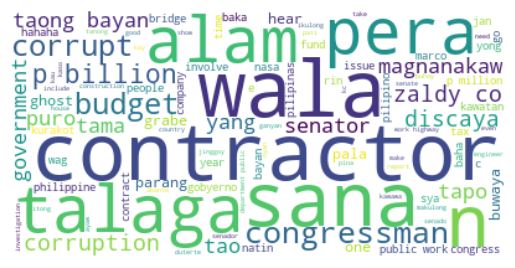

In [ ]:
wc = WordCloud(background_color="white",
               # colormap='plasma',
               max_words=100
               )

wc.generate(" ".join(text for text in cleaned_docs.cleaned_text))
plt.imshow(wc, interpolation='bilinear')
plt.axis("off")
plt.show()
plt.close()

## Term Frequency

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:

def plot_term_frequency(df, text_column='cleaned_text', top_n=25, stop_words='english'):
    """
    Plots the top N term frequencies from a DataFrame's text column.
    """
    vectorizer = CountVectorizer(stop_words=stop_words, max_features=2000)
    matrix = vectorizer.fit_transform(df[text_column])
    total = matrix.sum(axis=0)
    frequency = [(word, total[0, idx]) for word, idx in vectorizer.vocabulary_.items()]
    frequency_df = pd.DataFrame(frequency, columns=['term', 'frequency'])
    frequency_df = frequency_df.sort_values(by='frequency', ascending=False).reset_index(drop=True)
    ax = sns.barplot(data=frequency_df.head(top_n), x='term', y='frequency')
    ax.set_title(f'Top {top_n} Term Frequency Counts')
    plt.xticks(rotation=45)
    plt.show()
    plt.close()


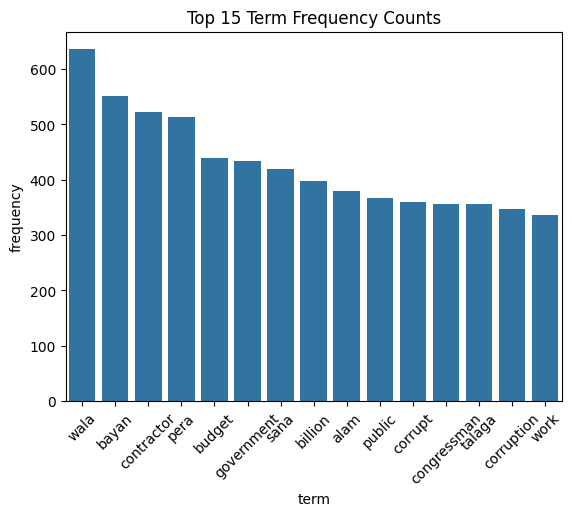

In [ ]:
plot_term_frequency(cleaned_docs, text_column='cleaned_text', top_n=15)

## Sentiment Intensity

In [ ]:
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer

# Download VADER lexicon if not already downloaded
nltk.download('vader_lexicon')

# Initialize the sentiment analyzer
senti = SentimentIntensityAnalyzer()

def sentiment_analysis(dataframe, textcolumn='text'):
    """
    Adds VADER sentiment scores to the dataframe for the specified text column.
    """
    for index, row in dataframe.iterrows():
        senti_score = senti.polarity_scores(str(row[textcolumn]))
        dataframe.loc[index, 'neg'] = senti_score['neg']
        dataframe.loc[index, 'neu'] = senti_score['neu']
        dataframe.loc[index, 'pos'] = senti_score['pos']
        dataframe.loc[index, 'compound'] = senti_score['compound']
    return dataframe

# Apply sentiment analysis to cleaned_docs
docs_sentiment = sentiment_analysis(docs, textcolumn='text')

# View the results
docs_sentiment[['text', 'neg', 'neu', 'pos', 'compound']].head()

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/bualoydgreat/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


,text,neg,neu,pos,compound
0,"MANILA, Philippines – The Department of Public...",0.033,0.917,0.049,0.5943
1,"MANILA, Philippines – Newly appointed Public W...",0.036,0.900,0.064,0.8857
2,"NEGROS OCCIDENTAL, Philippines – Hundreds of r...",0.074,0.845,0.081,0.8480
3,"MANILA, Philippines – The Philippine economy m...",0.062,0.889,0.049,-0.8100
4,"MANILA, Philippines – The House mega panel inv...",0.040,0.890,0.070,0.6808


In [ ]:
# Calculate average sentiment scores for YouTube comments
youtube_avg_sentiment = cleaned_docs[cleaned_docs['source'] == 'youtube'][['neg', 'neu', 'pos']].mean()
print("Average sentiment scores for YouTube comments:")
print(youtube_avg_sentiment)

Average sentiment scores for YouTube comments:
neg    0.045628
neu    0.915273
pos    0.037210
dtype: float64


# Latent Dirichlet Allocation

In [ ]:
LDA = LatentDirichletAllocation(
  n_components=3,  # no. of topics
  random_state=42  # random seed for replicability
)
LDA.fit(doc_term_matrix)

,n_components,3
,doc_topic_prior,None
,topic_word_prior,None
,learning_method,'batch'
,learning_decay,0.7
,learning_offset,10.0
,max_iter,10
,batch_size,128
,evaluate_every,-1
,total_samples,1000000.0
,perp_tol,0.1


In [ ]:
len(LDA.components_)

3

## Topic-Term Matrix

In [ ]:
topic_term_matrix = LDA.components_
pd.DataFrame(topic_term_matrix)

,0,1,2,3,4,5,6,7,8,9,...,8029,8030,8031,8032,8033,8034,8035,8036,8037,8038
0,0.333628,1.264051,0.333431,1.136346,0.333446,0.335136,0.333795,0.335049,0.348623,0.342099,...,0.334654,2.229131,4.299488,2.368535,17.255694,0.339065,7.333002,7.332597,4.333063,2.331243
1,3.226685,1.401947,2.333065,5.362378,0.336387,3.329772,0.334239,11.294764,0.349773,5.322333,...,0.352455,0.437454,0.333996,0.346905,0.386605,0.336291,0.333651,0.333361,0.333351,0.334353
2,0.439686,0.334003,0.333504,2.501276,2.330166,0.335092,2.331967,0.370187,2.301604,0.335568,...,2.312891,0.333415,0.366516,4.284560,0.357701,2.324644,0.333346,0.334042,0.333587,0.334404


In [ ]:
topic1 = topic_term_matrix[0]
topic1

# sort the scores from lowest to highest
# will return all terms
topic1.argsort()

# select top 10 terms within topic1
topic1_term_index = topic1.argsort()[-10:]

# convert back to words/terms
[vectorizer.get_feature_names_out()[index] for index in topic1_term_index]

['construction',
 'city',
 'president',
 'budget',
 'contractor',
 'marcos',
 'work',
 'billion',
 'public',
 'government']

In [ ]:
for topic_number, topic in enumerate(LDA.components_):
  print(f'The top 10 words for topic #{topic_number}')
  print(
    [
      vectorizer.get_feature_names_out()[term_index] for term_index in topic.argsort()[-10:]
    ]
  )
  print("\n")

The top 10 words for topic #0
['construction', 'city', 'president', 'budget', 'contractor', 'marcos', 'work', 'billion', 'public', 'government']


The top 10 words for topic #1
['tao', 'talaga', 'gobyerno', 'pilipinas', 'magnanakaw', 'taong', 'sana', 'wala', 'pera', 'bayan']


The top 10 words for topic #2
['mukha', 'corrupt', 'tama', 'congressman', 'abante', 'cong', 'wala', 'sen', 'zaldy', 'alam']




## Document-Topic Matrix

In [ ]:
doc_topic_matrix = LDA.transform(doc_term_matrix)
pd.DataFrame(doc_topic_matrix)

,0,1,2
0,0.995278,0.002350,0.002373
1,0.972109,0.020376,0.007515
2,0.997864,0.001067,0.001069
3,0.996719,0.001672,0.001608
4,0.987794,0.004214,0.007992
...,...,...,...
8618,0.711115,0.009110,0.279775
8619,0.015324,0.015578,0.969098
8620,0.037049,0.705320,0.257631
8621,0.028339,0.032129,0.939532


In [ ]:
cleaned_docs['Topic'] = doc_topic_matrix.argmax(axis=1)
cleaned_docs[['cleaned_text', 'source', 'Topic']]
cleaned_docs.to_excel('topic_documents.xlsx')

In [ ]:
cleaned_docs.query("Topic == 1 and source == 'rappler'")['text']
cleaned_docs.query("Topic == 1 and source == 'youtube'")['text']

155     How many days a week ba ang work ng mag iinspe...
156     Mas ok kung magtagalog kayo para mas maintindi...
162     Dapat maykapali buhay ng mga korakot na congre...
167                                         mga manloloko
172     isosoli ba nila ang pera at pinsala sa mga tao...
                              ...                        
8573    Magasarado na kayo pinagloloko nyo lng taong b...
8595                 Woooaaah the queen 🍌..kaassr boses 🤮
8597    isama muna din n dapat kunin ng state ang laha...
8599                                     Kasabwat din coa
8604    So kung meron PATUNAY ang GOBYERNO BA KAYA mLI...
Name: text, Length: 2127, dtype: object

## Visualize using PyLDAViz

In [ ]:
vocab = vectorizer.get_feature_names_out()
doc_lengths = [
  len(doc) for doc in docs['cleaned_text']
]
term_freq = doc_term_matrix.sum(axis=0)
term_freqs = np.array(term_freq).flatten()
vis_data = pyLDAvis.prepare(topic_term_matrix, doc_topic_matrix, doc_lengths, vocab, term_freqs)

pyLDAvis.display(vis_data)